In [1]:
import os
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

def make_combination(config_dict):
    keys, values = zip(*config_dict.items())
    return [dict(zip(keys, v)) for v in itertools.product(*values)]

In [2]:
UEA_MTSC30 = ['EthanolConcentration',
              'FaceDetection',
              'Handwriting',
              'Heartbeat',
              'JapaneseVowels',
              'PEMS-SF',
              'SelfRegulationSCP1',
              'SelfRegulationSCP2',
              'SpokenArabicDigits',
              'UWaveGestureLibrary',
              'ArticularyWordRecognition',
              'AtrialFibrillation',
              'BasicMotions',
              'CharacterTrajectories',
              'Cricket',
              'DuckDuckGeese',
              'EigenWorms',
              'Epilepsy',
              'ERing',
              'FingerMovements',
              'HandMovementDirection',
              'InsectWingbeat',
              'Libras',
              'LSST',
              'MotorImagery',
              'NATOPS',
              'PenDigits',
              'PhonemeSpectra',
              'RacketSports',
              'StandWalkJump']

In [3]:
from omegaconf import OmegaConf
data_info = OmegaConf.load(f"../data_classification.yaml")

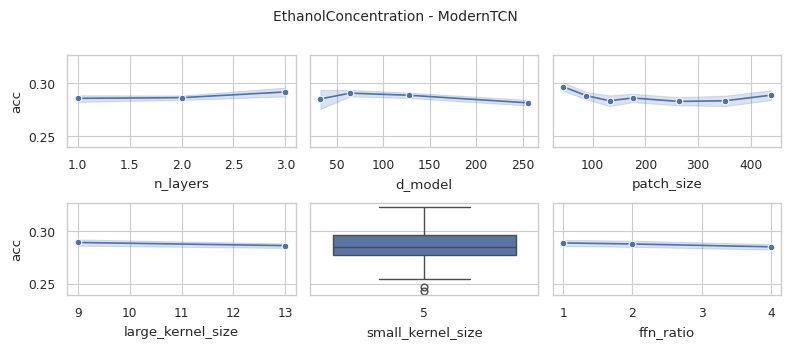

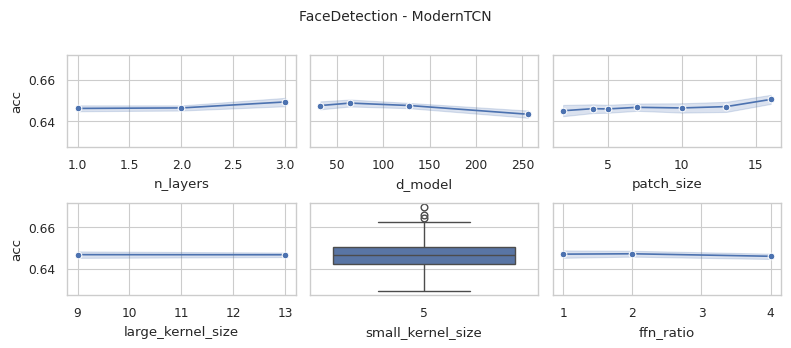

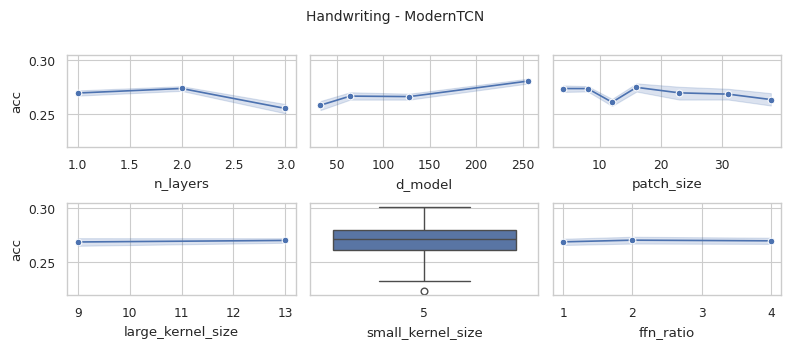

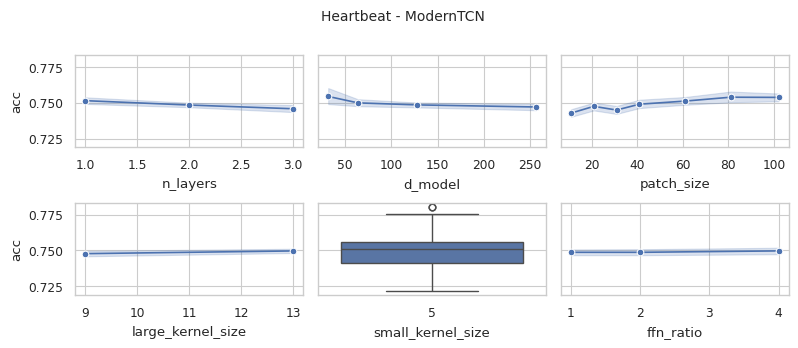

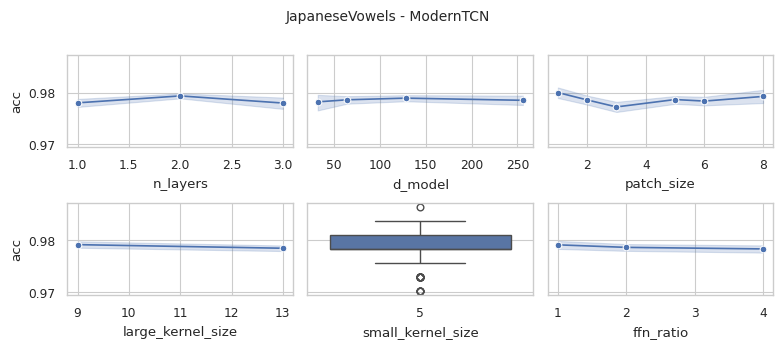

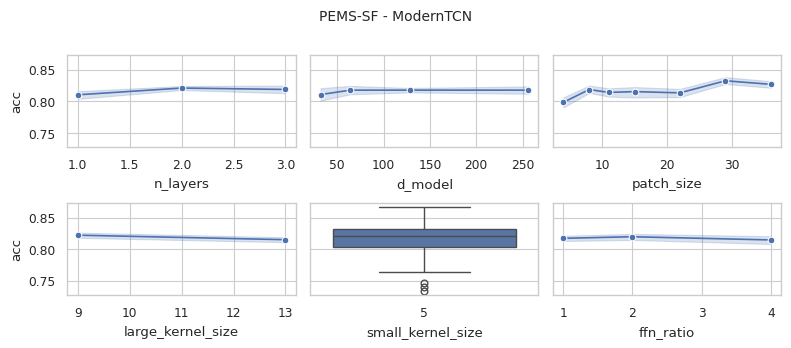

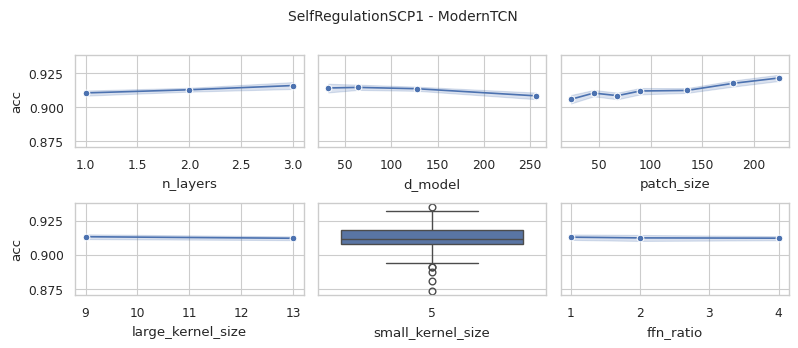

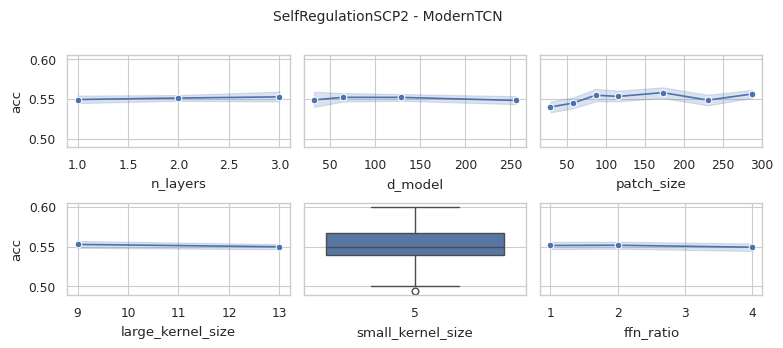

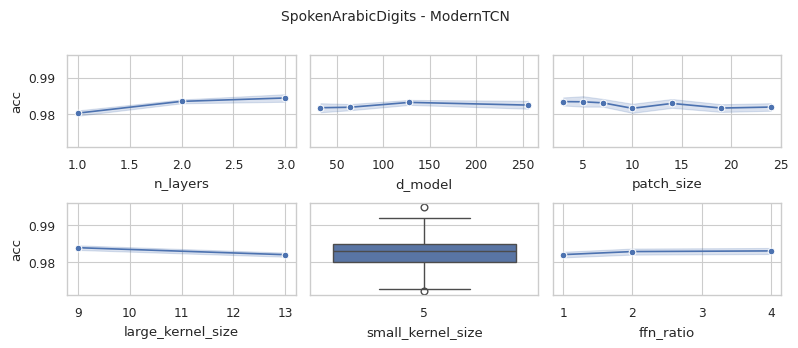

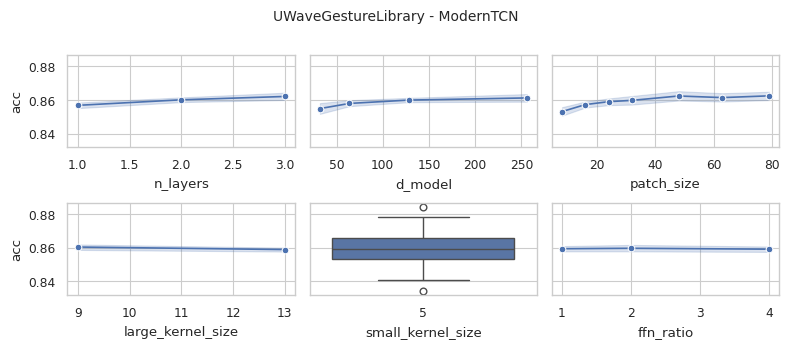

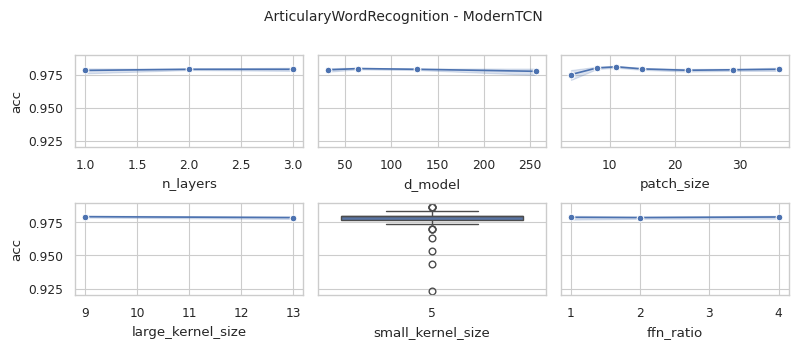

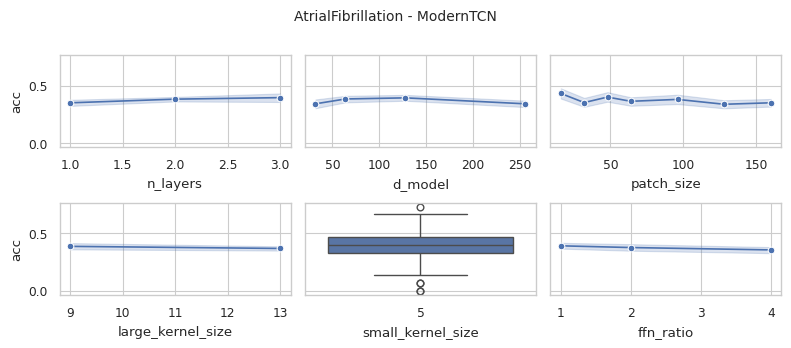

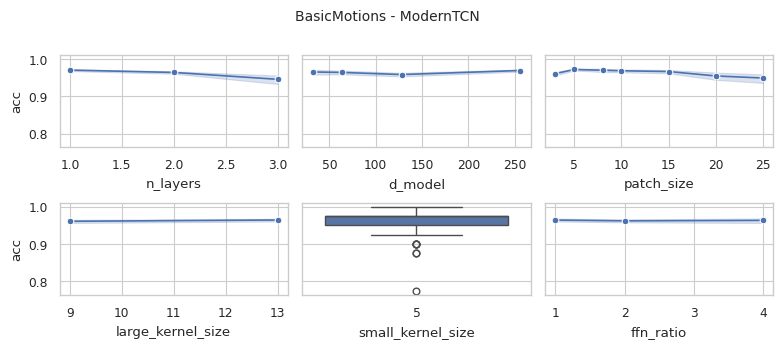

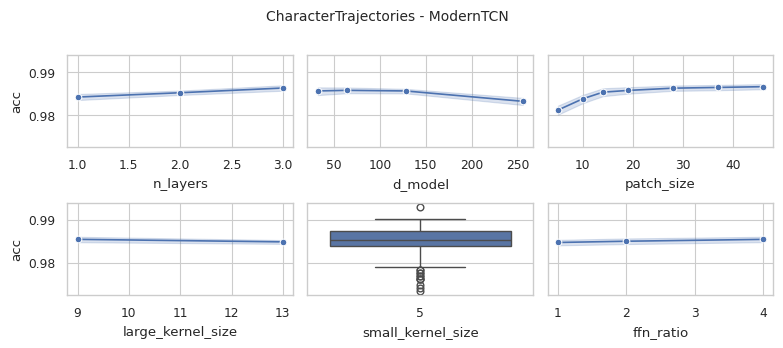

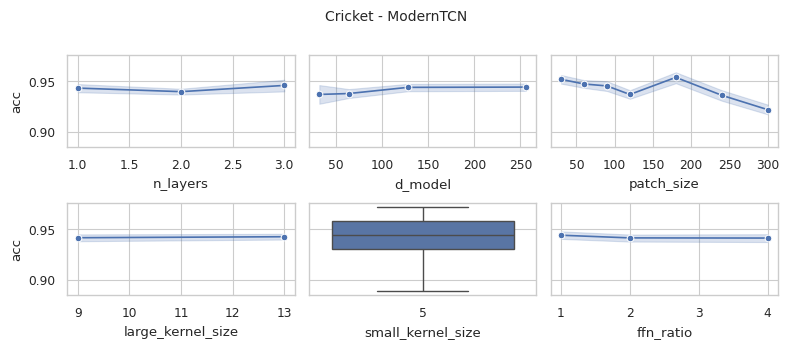

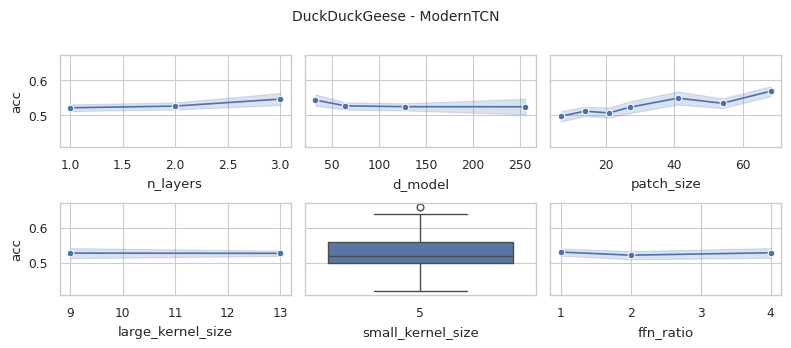

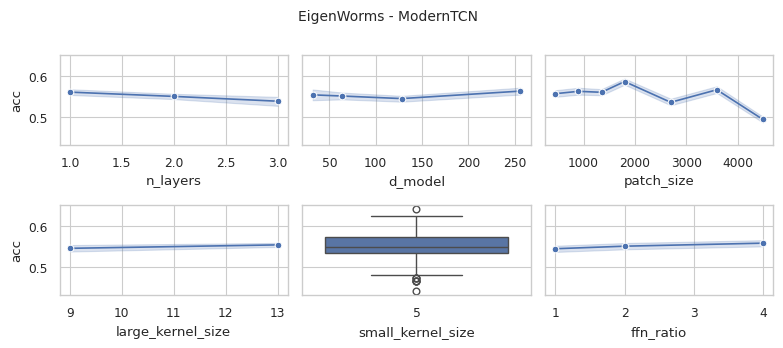

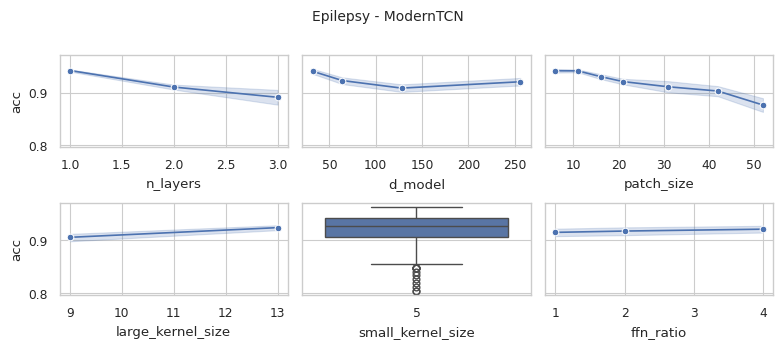

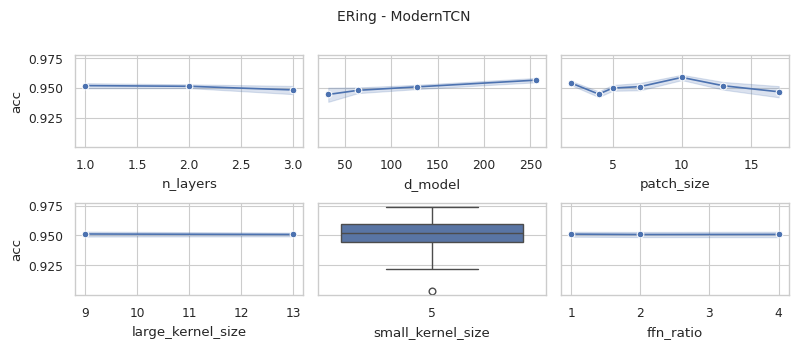

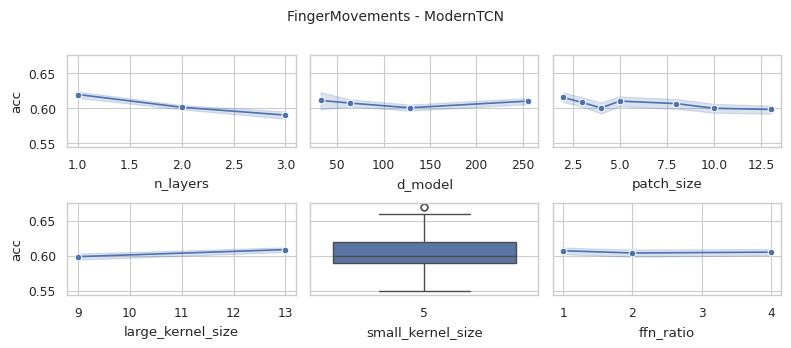

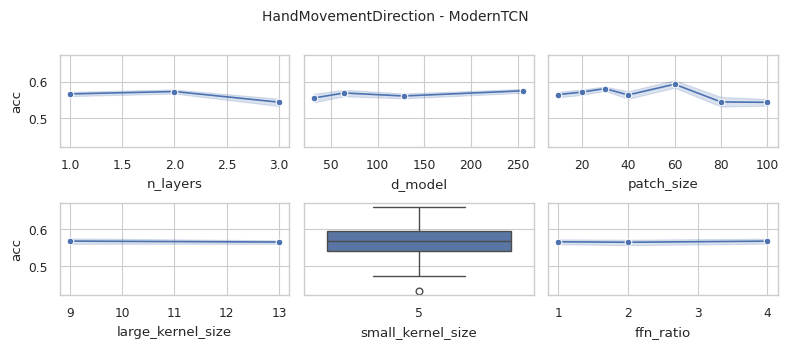

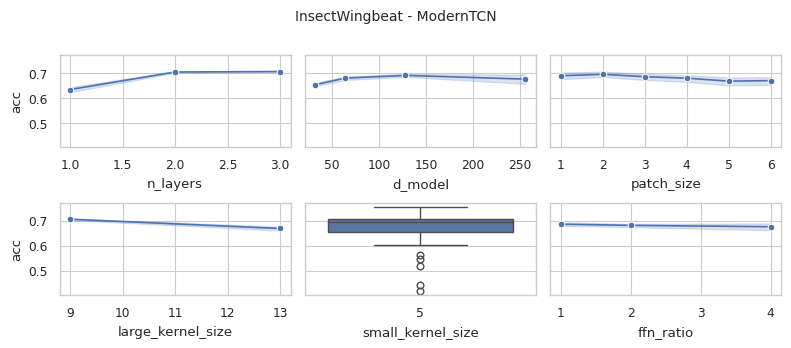

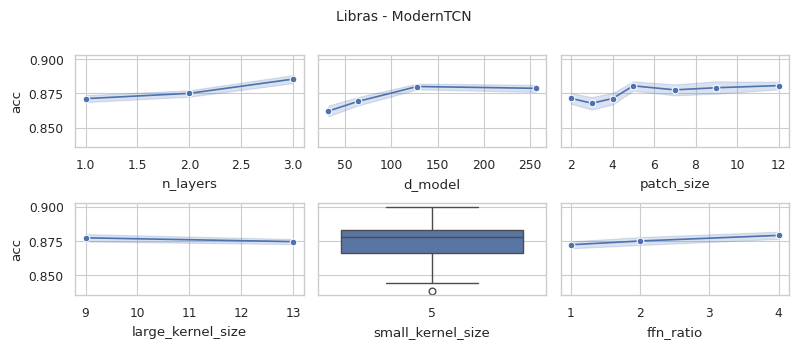

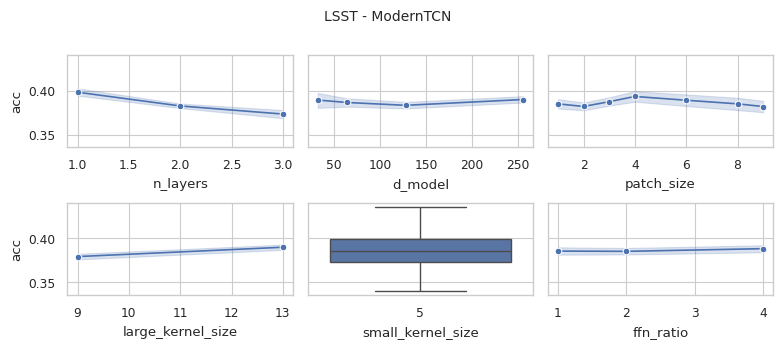

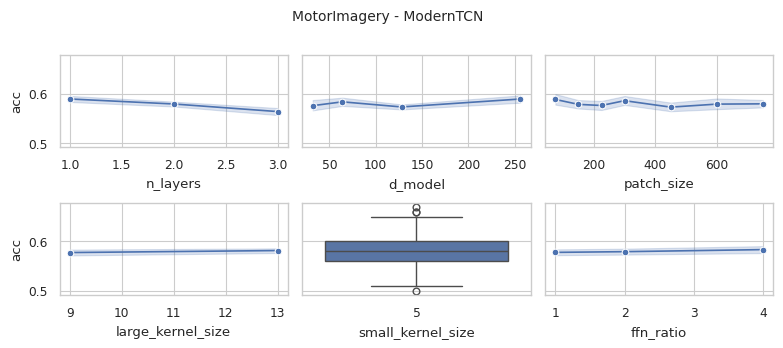

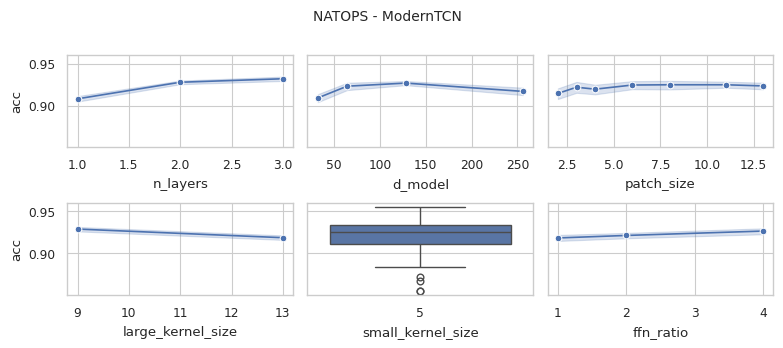

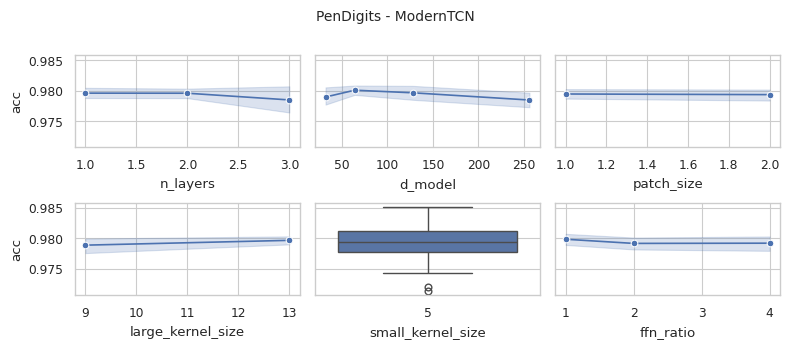

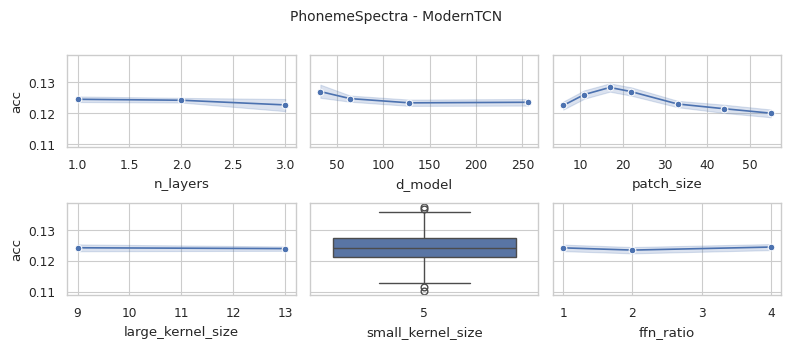

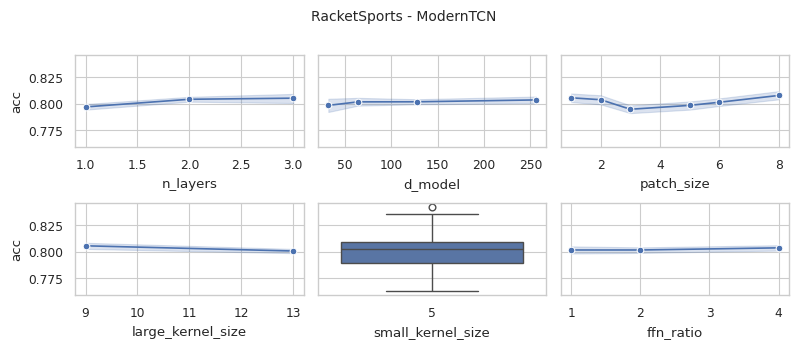

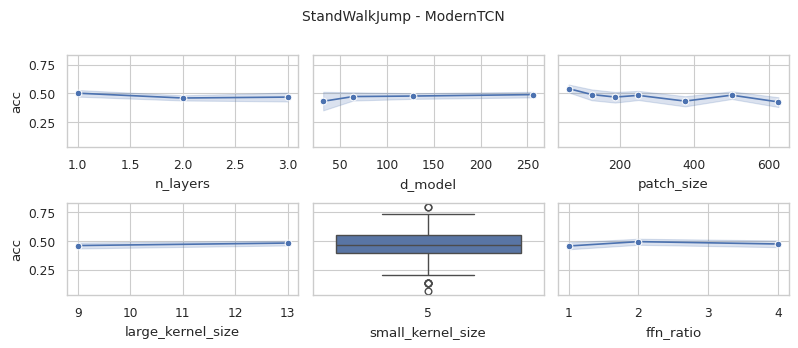

In [4]:
model = 'ModernTCN'
result_dict = dict()

for data_name in UEA_MTSC30:
    
    if os.path.exists(f'../03-full_results/{model}/{model}_CLS_{data_name}.out'):
        with open(f'../03-full_results/{model}/{model}_CLS_{data_name}.out', 'r') as file:
            data = file.read().splitlines()
    else:
        print('no file')
        continue


    result_lst = list()
    for i in range(len(data)):
        # classification_CLS_ArticularyWordRecognition_ModernTCN_UEA_ftM_sl144_ll0_pl0_dim32-64-128_nb1-1-1_lk13-13-13_sk5-5-5_ffr4_ps4_str2_multiFalse_mergedFalse_Exp_0
        if data[i].startswith('>>>>>>>testing : '):
            data_meta = list(data[i][16:-33].split('_'))
            data_meta[6] = int(data_meta[6].replace('sl', ''))
            data_meta[7] = int(data_meta[7].replace('ll', ''))
            data_meta[8] = int(data_meta[8].replace('pl', ''))
            data_meta[9] = int(data_meta[9].replace('dim', '').split('-')[-1])
            data_meta[10] = len(data_meta[10].replace('nb', '').split('-'))
            data_meta[11] = int(data_meta[11].replace('lk', '').split('-')[-1])
            data_meta[12] = int(data_meta[12].replace('sk', '').split('-')[-1])
            data_meta[13] = int(data_meta[13].replace('ffr', ''))
            data_meta[14] = int(data_meta[14].replace('ps', ''))
            data_meta[15] = int(data_meta[15].replace('str', ''))
            # data_meta[16] = data_meta[16].replace('multi', '')
            # data_meta[17] = data_meta[17].replace('merged', '')
            # data_meta[18] = data_meta[15].replace('exp', '')
            # data_meta[19] = data_meta[16].replace('desc', '')

            acc = data[i+3].replace('accuracy:', '')
            model_params = data[i+4].replace('model parameter : ', '')
            model_size = data[i+5].replace('model size : ', '').replace('MB', '')

            result_data = {
                # 'task': data_meta[0],
                # 'task_id': data_meta[1],
                'data_name': data_meta[2],
                'model': data_meta[3],
                # 'data': data_meta[4],
                # 'feature': data_meta[5],
                'seq_len': data_meta[6],
                # 'label_len': data_meta[7],
                # 'pred_len': data_meta[8],
                'd_model': data_meta[9],
                'n_layers': data_meta[10],
                'large_kernel_size': data_meta[11],
                'small_kernel_size': data_meta[12],
                'ffn_ratio': data_meta[13],
                'patch_size': data_meta[14],
                'patch_stride': data_meta[15],
                # 'multi': data_meta[16],
                # 'merged': data_meta[17],
                # 'exp': data_meta[18],
                # 'desc': data_meta[19],
                'acc': float(acc),
                'model_params': int(model_params),
                'model_size (MB)': float(model_size)
            }

            result_lst.append(result_data)

    result_df = pd.DataFrame(result_lst)
    os.makedirs(f'./{model}', exist_ok=True)
    result_df.to_csv(f'./{model}/{data_name}.csv', index=False)
    result_dict[data_name] = result_df.copy()

    cols = ['n_layers', 'd_model', 'patch_size',
            'large_kernel_size', 'small_kernel_size', 'ffn_ratio']
    num_cols, num_rows = 3, 2
    
    # # Boxplot
    # sns.set_theme(style="whitegrid")
    # sns.set_context("paper", font_scale=1)
    # fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(8, 3.5), sharey=True)
    # for i, col in enumerate(cols):
    #     sns.boxplot(x=col, y='acc', data=result_df, ax=axs[i//num_cols][i%num_cols], legend=False)
    # fig.suptitle(f'{data_name} - {model}', fontsize=10)
    # plt.tight_layout()
    # plt.subplots_adjust(top=0.85)
    # display(fig)
    # plt.close(fig)

    # Lineplot
    sns.set_theme(style="whitegrid")
    sns.set_context("paper", font_scale=1)
    fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(8, 3.5), sharey=True)
    for i, col in enumerate(cols):
        if result_df[col].unique().size == 1: 
            sns.boxplot(x=col, y='acc', data=result_df, ax=axs[i//num_cols][i%num_cols], legend=False)
        else:
            sns.lineplot(x=col, y='acc', data=result_df, ax=axs[i//num_cols][i%num_cols], legend=False, style='model', markers=True)
    fig.suptitle(f'{data_name} - {model}', fontsize=10)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    display(fig)
    plt.savefig(f'./{model}/{data_name}.png', dpi=300, bbox_inches='tight')
    plt.close(fig)
    

    # # Lineplot where each line represents same hyperparameter combination except one
    # fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(8, 3.5), sharey=True)
    # for i, col in enumerate(cols):
    #     col_rest = [c for c in cols if c != col]
    #     tmp_result = result_df.pivot_table(index=col_rest, columns=col, values='acc')
    #     tmp_result = pd.DataFrame(tmp_result.values, columns=tmp_result.columns)
    #     max_idx = tmp_result.mean(axis=1).idxmax()
    #     axs[i//num_cols][i%num_cols].plot(tmp_result.T, marker='.', color='#111', alpha=0.2)
    #     axs[i//num_cols][i%num_cols].plot(tmp_result.iloc[max_idx].T, marker='o', color='red', alpha=0.5)
    #     axs[i//num_cols][i%num_cols].grid(False)
    #     axs[i//num_cols][i%num_cols].set_xlabel(col)
    # fig.suptitle(f'{data_name} - {model}', fontsize=10)
    # plt.tight_layout()
    # plt.subplots_adjust(top=0.85)
    # display(fig)
    # plt.close(fig)
    

In [5]:
model_configs = {
    "ffn_ratio" : [1, 2, 4],
    "patch_size_ratio" : [2.5, 5, 7.5, 10, 15, 20, 25], 

    "n_layers - large_kernel - small_kernel - last_dims" : [
        (1, 13, 5, 32), (1, 13, 5, 64), (1, 13, 5, 128), (1, 13, 5, 256),
        (2, 9, 5, 64), (2, 9, 5, 128), (2, 9, 5, 256),
        (2, 13, 5, 64), (2, 13, 5, 128), (2, 13, 5, 256),
        (3, 9, 5, 128), (3, 13, 5, 128),
    ],
}

hyperparameter_combinations = make_combination(model_configs)

acc_all_df = pd.DataFrame(index=UEA_MTSC30, 
                          columns=[str(hp_comb) for hp_comb in hyperparameter_combinations])
for data_name in UEA_MTSC30:
    acc_data_dict = dict()
    for hyperparameter_combination in hyperparameter_combinations:
        seq_len = data_info[f'CLS_{data_name}']["seq_len"]
        enc_in = data_info[f'CLS_{data_name}']["enc_in"]

        ffn_ratio = hyperparameter_combination['ffn_ratio']
        n_layers, large_size, small_size, last_dims = hyperparameter_combination['n_layers - large_kernel - small_kernel - last_dims']

        patch_ratio = hyperparameter_combination['patch_size_ratio']
        patch_size = max(2, math.ceil((patch_ratio/100) * seq_len))
        patch_stride = max(1, math.ceil((patch_ratio/100) * seq_len * 1/2))
        
        if result_dict.get(data_name) is None:
            continue

        tmp = result_dict[data_name]
        try:
            acc = tmp[
                (tmp['n_layers'] == n_layers) &
                (tmp['large_kernel_size'] == large_size) &
                (tmp['small_kernel_size'] == small_size) &
                (tmp['d_model'] == last_dims) &
                (tmp['patch_size'] == patch_size) &
                (tmp['patch_stride'] == patch_stride) &
                (tmp['ffn_ratio'] == ffn_ratio)
            ]['acc'].values[0]
        except:
            acc = None
            print(f'no acc for {data_name} with {hyperparameter_combination}')
        acc_data_dict[str(hyperparameter_combination)] = acc

    acc_all_df.loc[data_name] = pd.Series(acc_data_dict)



no acc for PEMS-SF with {'ffn_ratio': 4, 'patch_size_ratio': 2.5, 'n_layers - large_kernel - small_kernel - last_dims': (1, 13, 5, 256)}
no acc for PEMS-SF with {'ffn_ratio': 4, 'patch_size_ratio': 2.5, 'n_layers - large_kernel - small_kernel - last_dims': (2, 9, 5, 256)}
no acc for PEMS-SF with {'ffn_ratio': 4, 'patch_size_ratio': 2.5, 'n_layers - large_kernel - small_kernel - last_dims': (2, 13, 5, 256)}
no acc for PEMS-SF with {'ffn_ratio': 4, 'patch_size_ratio': 5, 'n_layers - large_kernel - small_kernel - last_dims': (1, 13, 5, 256)}
no acc for PEMS-SF with {'ffn_ratio': 4, 'patch_size_ratio': 5, 'n_layers - large_kernel - small_kernel - last_dims': (2, 9, 5, 256)}
no acc for PEMS-SF with {'ffn_ratio': 4, 'patch_size_ratio': 5, 'n_layers - large_kernel - small_kernel - last_dims': (2, 13, 5, 256)}
no acc for PEMS-SF with {'ffn_ratio': 4, 'patch_size_ratio': 7.5, 'n_layers - large_kernel - small_kernel - last_dims': (1, 13, 5, 256)}
no acc for PEMS-SF with {'ffn_ratio': 4, 'patch_s

In [6]:
acc_all_df.median(axis=1)

EthanolConcentration         0.285171
FaceDetection                0.646708
Handwriting                  0.271176
Heartbeat                     0.75122
JapaneseVowels               0.978378
PEMS-SF                      0.820809
SelfRegulationSCP1           0.911263
SelfRegulationSCP2               0.55
SpokenArabicDigits           0.982947
UWaveGestureLibrary          0.859375
ArticularyWordRecognition        0.98
AtrialFibrillation                0.4
BasicMotions                    0.975
CharacterTrajectories        0.985376
Cricket                      0.944444
DuckDuckGeese                    0.52
EigenWorms                   0.549618
Epilepsy                     0.927536
ERing                        0.951852
FingerMovements                   0.6
HandMovementDirection        0.567568
InsectWingbeat                 0.6964
Libras                       0.877778
LSST                         0.385239
MotorImagery                     0.58
NATOPS                          0.925
PenDigits   

In [7]:
acc_all_df.loc[:,'max'] = acc_all_df.max(axis=1)
acc_all_df.loc['avg'] = acc_all_df.mean(axis=0)

pd.set_option('future.no_silent_downcasting', True)
acc_all_df_fillna = acc_all_df.T.fillna(acc_all_df.median(axis=1)).T
acc_all_df_fillna.sort_values(by='avg', ascending=False, inplace=True, axis=1)
acc_all_df_fillna

,max,"{'ffn_ratio': 4, 'patch_size_ratio': 2.5, 'n_layers - large_kernel - small_kernel - last_dims': (2, 13, 5, 128)}","{'ffn_ratio': 4, 'patch_size_ratio': 10, 'n_layers - large_kernel - small_kernel - last_dims': (3, 13, 5, 128)}","{'ffn_ratio': 4, 'patch_size_ratio': 5, 'n_layers - large_kernel - small_kernel - last_dims': (2, 13, 5, 128)}","{'ffn_ratio': 2, 'patch_size_ratio': 15, 'n_layers - large_kernel - small_kernel - last_dims': (1, 13, 5, 256)}","{'ffn_ratio': 2, 'patch_size_ratio': 2.5, 'n_layers - large_kernel - small_kernel - last_dims': (2, 9, 5, 64)}","{'ffn_ratio': 2, 'patch_size_ratio': 5, 'n_layers - large_kernel - small_kernel - last_dims': (2, 9, 5, 256)}","{'ffn_ratio': 4, 'patch_size_ratio': 15, 'n_layers - large_kernel - small_kernel - last_dims': (1, 13, 5, 256)}","{'ffn_ratio': 2, 'patch_size_ratio': 15, 'n_layers - large_kernel - small_kernel - last_dims': (2, 13, 5, 128)}","{'ffn_ratio': 1, 'patch_size_ratio': 5, 'n_layers - large_kernel - small_kernel - last_dims': (2, 9, 5, 64)}",...,"{'ffn_ratio': 1, 'patch_size_ratio': 2.5, 'n_layers - large_kernel - small_kernel - last_dims': (2, 13, 5, 128)}","{'ffn_ratio': 2, 'patch_size_ratio': 25, 'n_layers - large_kernel - small_kernel - last_dims': (2, 9, 5, 128)}","{'ffn_ratio': 1, 'patch_size_ratio': 2.5, 'n_layers - large_kernel - small_kernel - last_dims': (1, 13, 5, 256)}","{'ffn_ratio': 2, 'patch_size_ratio': 20, 'n_layers - large_kernel - small_kernel - last_dims': (3, 13, 5, 128)}","{'ffn_ratio': 4, 'patch_size_ratio': 25, 'n_layers - large_kernel - small_kernel - last_dims': (2, 13, 5, 256)}","{'ffn_ratio': 1, 'patch_size_ratio': 25, 'n_layers - large_kernel - small_kernel - last_dims': (1, 13, 5, 32)}","{'ffn_ratio': 1, 'patch_size_ratio': 5, 'n_layers - large_kernel - small_kernel - last_dims': (1, 13, 5, 32)}","{'ffn_ratio': 2, 'patch_size_ratio': 25, 'n_layers - large_kernel - small_kernel - last_dims': (2, 13, 5, 128)}","{'ffn_ratio': 1, 'patch_size_ratio': 20, 'n_layers - large_kernel - small_kernel - last_dims': (3, 9, 5, 128)}","{'ffn_ratio': 4, 'patch_size_ratio': 15, 'n_layers - large_kernel - small_kernel - last_dims': (1, 13, 5, 32)}"
EthanolConcentration,0.323194,0.304183,0.285171,0.292776,0.277567,0.30038,0.304183,0.281369,0.281369,0.292776,...,0.304183,0.281369,0.292776,0.281369,0.273764,0.319392,0.296578,0.292776,0.288973,0.304183
FaceDetection,0.669977,0.658627,0.647276,0.64983,0.639898,0.650114,0.648127,0.648127,0.643871,0.649262,...,0.642168,0.658627,0.640182,0.659194,0.647843,0.656924,0.650397,0.645289,0.644154,0.6521
Handwriting,0.301176,0.265882,0.247059,0.271765,0.294118,0.278824,0.272941,0.290588,0.287059,0.28,...,0.264706,0.270588,0.276471,0.262353,0.289412,0.242353,0.258824,0.271765,0.254118,0.254118
Heartbeat,0.780488,0.731707,0.75122,0.736585,0.741463,0.736585,0.731707,0.75122,0.765854,0.760976,...,0.736585,0.765854,0.741463,0.741463,0.756098,0.760976,0.756098,0.760976,0.741463,0.760976
JapaneseVowels,0.983784,0.978378,0.975676,0.978378,0.97027,0.981081,0.975676,0.978378,0.981081,0.981081,...,0.981081,0.981081,0.983784,0.975676,0.983784,0.981081,0.975676,0.981081,0.978378,0.981081
PEMS-SF,0.867052,0.83237,0.820809,0.803468,0.82659,0.797688,0.83237,0.820809,0.82659,0.82659,...,0.791908,0.83237,0.768786,0.815029,0.820809,0.83237,0.820809,0.815029,0.83815,0.780347
SelfRegulationSCP1,0.935154,0.911263,0.921502,0.897611,0.911263,0.914676,0.904437,0.918089,0.90785,0.918089,...,0.90785,0.924915,0.918089,0.921502,0.918089,0.921502,0.918089,0.924915,0.931741,0.921502
SelfRegulationSCP2,0.6,0.55,0.594444,0.538889,0.516667,0.588889,0.538889,0.594444,0.555556,0.538889,...,0.588889,0.566667,0.538889,0.527778,0.538889,0.572222,0.55,0.544444,0.55,0.572222
SpokenArabicDigits,0.994998,0.986357,0.986812,0.984993,0.979081,0.986357,0.989086,0.975898,0.979536,0.989541,...,0.982265,0.986812,0.978172,0.984084,0.9809,0.980446,0.974989,0.978627,0.982719,0.987267
UWaveGestureLibrary,0.884375,0.846875,0.865625,0.859375,0.859375,0.85,0.853125,0.8

In [8]:
pd.set_option("display.precision", 14)
acc_all_df[acc_all_df_fillna.columns].iloc[:,[0,1]]*100

,max,"{'ffn_ratio': 4, 'patch_size_ratio': 2.5, 'n_layers - large_kernel - small_kernel - last_dims': (2, 13, 5, 128)}"
EthanolConcentration,32.31939163498099,30.41825095057034
FaceDetection,66.99772985244041,65.86265607264473
Handwriting,30.11764705882353,26.58823529411764
Heartbeat,78.04878048780488,73.17073170731707
JapaneseVowels,98.37837837837839,97.83783783783784
PEMS-SF,86.70520231213872,83.23699421965318
SelfRegulationSCP1,93.51535836177474,91.12627986348123
SelfRegulationSCP2,60.0,55.00000000000001
SpokenArabicDigits,99.49977262391997,98.63574351978171
UWaveGestureLibrary,88.4375,84.6875
